In [ ]:
# Ground Truth Test - 5D Data Creation

# Create 5-dimensional data with structure: (channel, value, z, y, x)

## Create Empty 5D Data Array

Create a 5-dimensional array initialized with zeros.


In [120]:
import numpy as np

# Define dimensions
num_channels = 4  # Channels: 1, 2, 3, 4 (indices 0-3)
value_range = (0, 10)  # Values: 0 to 10 (11 values, indices 0-10)
z_range = (0, 11)  # z: 0 to 11 (12 values, indices 0-11)
y_range = (0, 86)  # y: 0 to 86 (87 values, indices 0-86)
x_range = (0, 171)  # x: 0 to 171 (172 values, indices 0-171)

# Calculate array dimensions
num_values = value_range[1] - value_range[0] + 1  # 11 values (0-10)
z_dim = z_range[1] - z_range[0] + 1  # 12 values (0-11)
y_dim = y_range[1] - y_range[0] + 1  # 87 values (0-86)
x_dim = x_range[1] - x_range[0] + 1  # 172 values (0-171)

# Create 5D array initialized with zeros
# Shape: (channel, value, z, y, x)
data = np.zeros((num_channels, num_values, z_dim, y_dim, x_dim), dtype=np.int8)
# Generate random values for each (z, y, x) position
for i in range(0, 4):
    for z in range(z_dim):
        # Channel 0: x ranges 38+40*i to 43+40*i, for all y
        for y in range(y_dim):
            for x in range(38+20*i, 43+20*i):
                random_value = np.random.randint(6, 11)
                data[0, random_value, z, y, x] = 1
        # Channel 1: y ranges 18+20*i to 23+20*i, for all x
        for y in range(18+20*i, 23+20*i):
            for x in range(x_dim):
                random_value = np.random.randint(6, 11)
                data[1, random_value, z, y, x] = 1
        # Channel 2: 3 diagonal lines with slope 1 (y = x + c) covering whole x,y space
        strip_width = 5  # Width of each diagonal strip
        # 3 lines distributed across the space: y-x ranges from -171 to 86
        c_values = [-60, 0, 60]  # 3 lines: y=x-60, y=x, y=x+60 (covers lower, center, upper regions)
        for c in c_values:
            for y in range(y_dim):
                for x in range(x_dim):
                    # Check if y - x is close to c (within strip_width)
                    if abs(y - x - c) <= strip_width:
                        random_value = np.random.randint(6, 11)
                        data[2, random_value, z, y, x] = 1
        # Channel 3: 3 diagonal lines with slope -1 (y = -x + d) covering whole x,y space
        strip_width = 5  # Width of each diagonal strip
        # 3 lines distributed across the space: y+x ranges from 0 to 257
        d_values = [60, 120, 180]  # 3 lines: y=-x+50, y=-x+128, y=-x+206 (covers whole space)
        for d in d_values:
            for y in range(y_dim):
                for x in range(x_dim):
                    # Check if y + x is close to d (within strip_width) for slope -1
                    if abs(y + x - d) <= strip_width:
                        random_value = np.random.randint(6, 11)
                        data[3, random_value, z, y, x] = 1
print(f"Created 5D data array with shape: {data.shape}")
print(f"Dimensions breakdown:")
print(f"  - Channels: {num_channels} (1, 2, 3, 4)")
print(f"  - Values: {num_values} (0 to {value_range[1]})")
print(f"  - Z: {z_dim} (0 to {z_range[1]})")
print(f"  - Y: {y_dim} (0 to {y_range[1]})")
print(f"  - X: {x_dim} (0 to {x_range[1]})")
print(f"\nData type: {data.dtype}")
print(f"Total elements: {data.size:,}")
print(f"Memory size: {data.nbytes / 1024 / 1024:.2f} MB")
print(f"\nAll values initialized to: {data.min()} (zero)")

# Save the empty data
np.save('groundtruth_5d_empty.npy', data)
print(f"\n✓ Empty 5D data saved to: groundtruth_5d_empty.npy")


Created 5D data array with shape: (4, 11, 12, 87, 172)
Dimensions breakdown:
  - Channels: 4 (1, 2, 3, 4)
  - Values: 11 (0 to 10)
  - Z: 12 (0 to 11)
  - Y: 87 (0 to 86)
  - X: 172 (0 to 171)

Data type: int8
Total elements: 7,900,992
Memory size: 7.53 MB

All values initialized to: 0 (zero)

✓ Empty 5D data saved to: groundtruth_5d_empty.npy


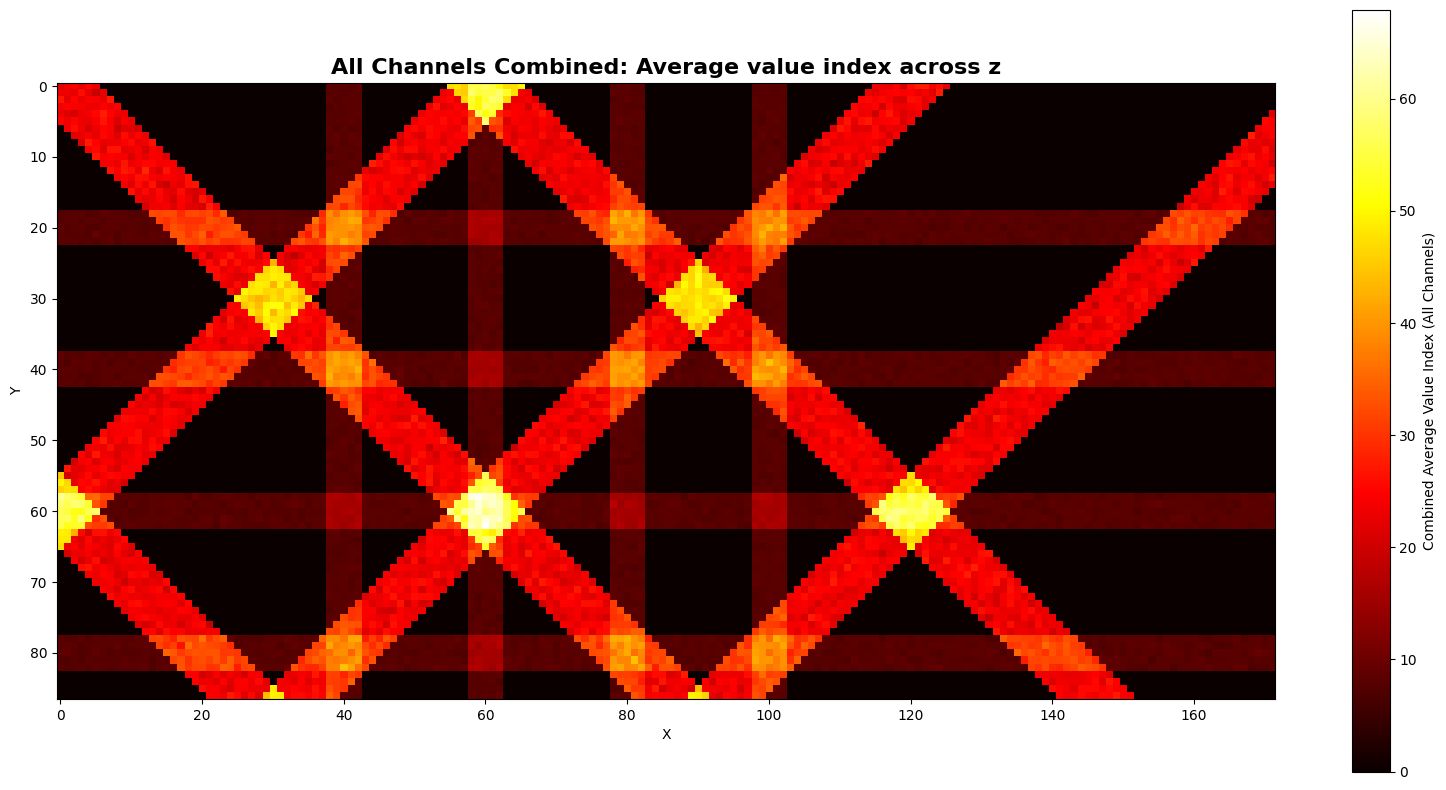

In [123]:
import matplotlib.pyplot as plt

# Combine all channels into one image (sum all channels)
combined_image = np.zeros((y_dim, x_dim))
for channel in range(4):
    # Calculate average value index across z for each channel
    value_indices = (data[channel] * np.arange(11)[:, None, None, None]).sum(axis=0)
    # Add to combined image
    combined_image += value_indices.mean(axis=0)

# Plot combined image
plt.figure(figsize=(16, 8))
plt.imshow(combined_image, cmap='hot')
plt.colorbar(label='Combined Average Value Index (All Channels)')
plt.title('All Channels Combined: Average value index across z', fontsize=16, fontweight='bold')
plt.xlabel('X')
plt.ylabel('Y')
plt.tight_layout()
plt.show()
